# Hotel Booking Analysis
## Project Overview

This project analyzes hotel booking data to understand the characteristics associated with booking cancellations.

In [71]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
# load the data
df = pd.read_csv('C:/Users/USER/Downloads/Data Annalytics and Data Apps/data/Hotel bookings Analysis/hotel_bookings.csv')

In [73]:
# preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [74]:
# dataset shape
df.shape

(119390, 32)

The dataset has 119390 rows and 32 columns

In [75]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

The dataset has some few missing values

In [76]:
# check for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [77]:
# check for duplicate values
df.duplicated().sum()

np.int64(31994)

You need to ask yourself in what context do the duplicates exist before removing them

# Data Cleaning

In [78]:
# Fill Agent and Company with 0 (meaning booked directly)
df['agent']=df['agent'].fillna(0)
df['company']=df['company'].fillna(0)

In [79]:
df.shape

(119390, 32)

In [80]:
# Fill children with 0
df['children'] = df['children'].fillna(0)

In [81]:
df.shape

(119390, 32)

In [82]:
# Changig  Children column from float to int
df['children'] = df['children'].astype(int)

In [83]:
# drop the rest of the missing values
df=df.dropna()

In [84]:
# drop duplicate values
df=df.drop_duplicates()

# Validation

In [85]:
# recheck for missing values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [86]:
# recheck for duplicates
df.duplicated().sum()

np.int64(0)

In [87]:
# recheck the dataset shape
df.shape

(86944, 32)

In [88]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Feature Engineering

In [89]:
# calculate total nights
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [90]:
# calculate the total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [91]:
# Check is_family
df['is_family']=(df['babies']>0)+(df['children']>0)

In [92]:
# create 'season' based on the arrival month
month_to_season = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall ', 'October': 'Fall', 'November': 'Fall'
}
df['season'] = df['arrival_date_month'].map(month_to_season)

In [93]:
# preview the data
df.head(112)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,0,2,False,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,0,2,False,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,1,1,False,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,1,1,False,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,2,2,False,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,Resort Hotel,0,78,2015,July,27,4,2,5,2,...,Transient,139.00,0,2,Check-Out,2015-07-11,7,3,True,Summer
112,Resort Hotel,0,52,2015,July,27,4,2,5,2,...,Transient,67.24,0,0,Check-Out,2015-07-11,7,2,False,Summer
113,Resort Hotel,0,29,2015,July,27,4,2,6,3,...,Transient,116.50,0,1,Check-Out,2015-07-12,8,3,False,Summer
114,Resort Hotel,1,101,2015,July,27,4,2,6,2,...,Transient,96.30,0,1,Canceled,2015-05-12,8,2,False,Summer


# Exploratory Data Analysis (EDA)

TypeError: 'str' object is not callable

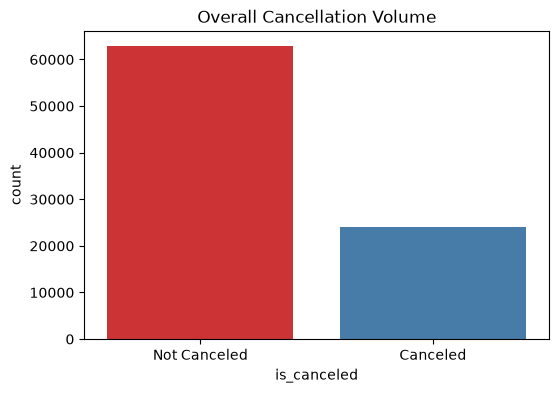

In [94]:
#Overall overall cancellation distribution
plt.figure(figsize=(6, 4))
df['is_canceled']=df['is_canceled'].map({0:'Not Canceled', 1:'Canceled'})
sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette= 'Set1',legend=False)
plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('cancellation.png')
plt.show()

# Calculate the cancellation rate
cancel_pct=df['is_canceled'].value_counts(normalize=True)*100
print(cancel_pct)


The cancellation rate is 27.6% implying that 1 in 3 bookings is cancelled.Thus the hotels cannot rely on the initial booking number s for staffing or food ordering.Management must utilize an overbooking strategy to ensure the hotel is full on any given night

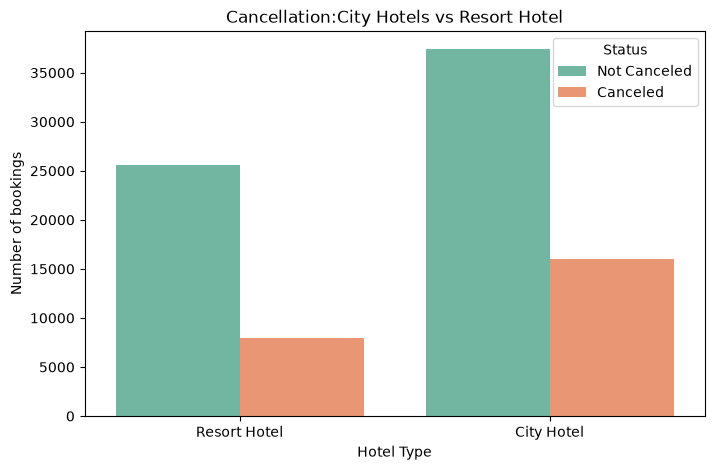

hotel         is_canceled 
City Hotel    Not Canceled    69.965557
              Canceled        30.034443
Resort Hotel  Not Canceled    76.296164
              Canceled        23.703836
Name: proportion, dtype: float64

In [ ]:
# Hotel type comparision
# Does the hotel type affect the cancellation rate? We will compare the city hotels to resort hotels to see if their customer bases behave differently. We will use a bar chart to visualize the cancellation rate for each hotel type.
plt.figure(figsize=(8, 5))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette='Set2')
plt.title('Cancellation:City Hotels vs Resort Hotel')
plt.ylabel('Number of bookings')
plt.xlabel('Hotel Type')
plt.legend(title='Status')
plt.savefig('hoteltype.png')
plt.show()

# Calculate rates per hotel type
df.groupby('hotel')['is_canceled'].value_counts(normalize=True)*100

City hotels see significantly higher booking volumes but they also suffer from a much higher cancellation rate compared to Resort Hotels.City trips are often short,impulsive or tied to business meetings that get moved.Resort trips are usually planned(often flights) making guests less likely to abandon their plans.

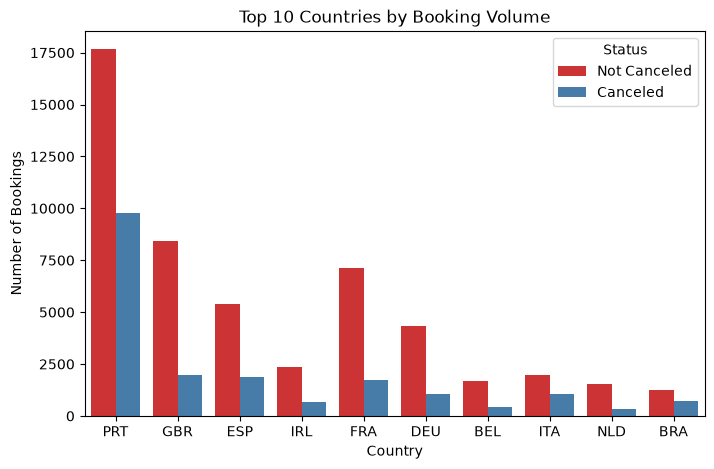

In [ ]:
# Understanding geographical origin of our customers
plt.figure(figsize=(8,5))
#Get top ten countries by volume
top_10_countries=df['country'].value_counts().head(10).index

sns.countplot(
    x='country',
    hue='is_canceled',
    data=df[df['country'].isin(top_10_countries)],
    palette='Set1'
)
plt.title('Top 10 Countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('countries.png')
plt.show()

Residents of Portugal had more cancellations since it is easier for locals to cancel compared to foreign nationals
PRT(Portugal) generate the highest booking volume of bookings, but it also has a staggering cancellation rate. Because the hotels in this dataset are located in portugal, these are local residents. Locals often book multiple hotels as 'backups' for weekend getaways because they don't have to commit to flights.

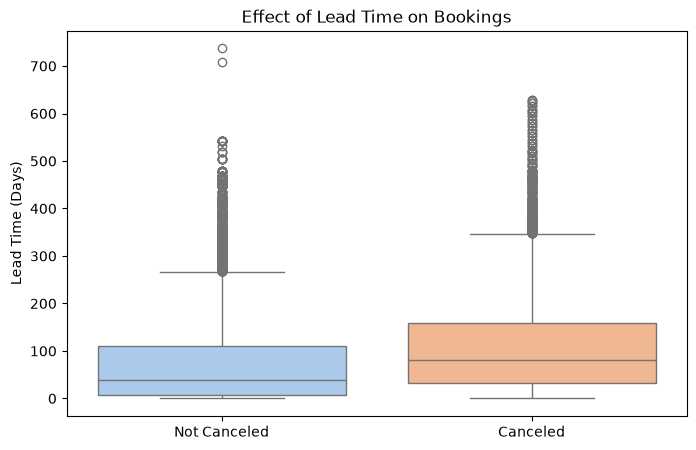

In [ ]:
# Lead time analysis: number of days between booking and arrival
plt.figure(figsize=(8, 5))
sns.boxplot(
	data=df,
	x='is_canceled',
	y='lead_time',
	hue='is_canceled',
	palette='pastel'
)
plt.title('Effect of Lead Time on Bookings')
plt.ylabel('Lead Time (Days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The median lead time for cancelled bookings is higher.Simply put:the earlier someone books the more time they have to change their mind and cancel,find a better deal,or experience a schedule change.

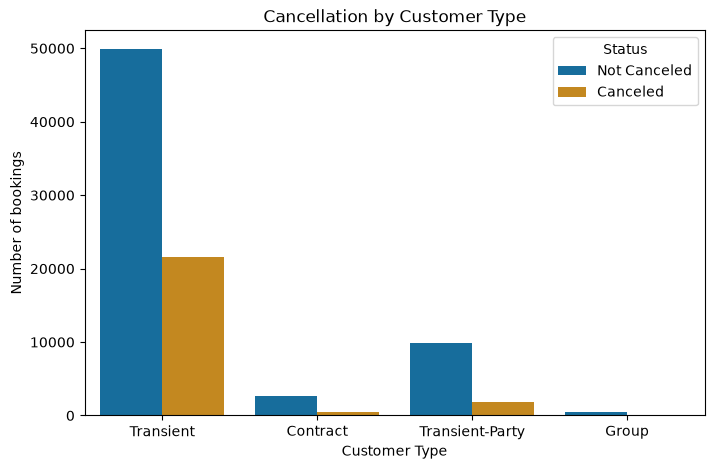

In [ ]:
# Customer Type Analysis
# are solo/transient travellers more volatile than large groups or corporate conracts?
plt.figure(figsize=(8,5))
sns.countplot(
    x='customer_type',
    hue='is_canceled',
    data=df,
    palette='colorblind'
)
plt.title('Cancellation by Customer Type')
plt.ylabel('Number of bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()


'Transient' travelers (independent travelers not part of a group) account for the vast majority of both bookings and cancellations. Conversely, 'Groups' and 'Contract' bookings are much more stable. Recommendation: The sales team should prioritize securing more B2B (business-to-business) contracts and group events to build a stable, guaranteed revenue base that protects against the volatility of individual transients.

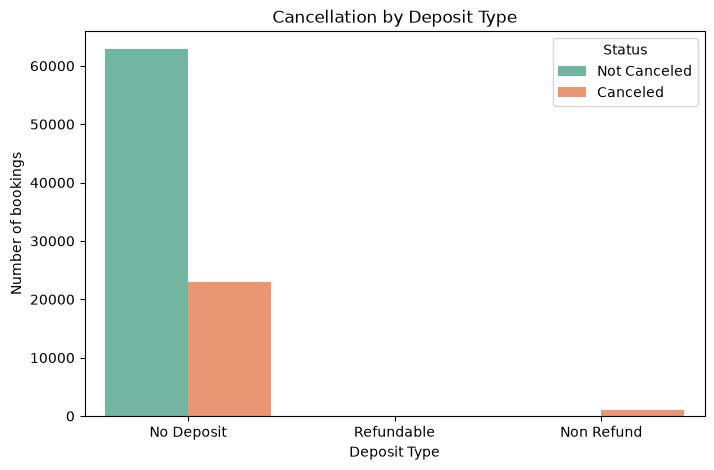

In [ ]:
# Impact of deposit type on cancellations
plt.figure(figsize=(8, 5))
sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df,
    palette='Set2'
)
plt.title('Cancellation by Deposit Type')
plt.ylabel('Number of bookings')
plt.xlabel('Deposit Type')
plt.legend(title='Status')
plt.savefig('deposittype.png')
plt.show()

The majority of the bookings have no deposit.Management should implement a compulsory and refundable deposit system to minimize the volatility.

TypeError: 'str' object is not callable

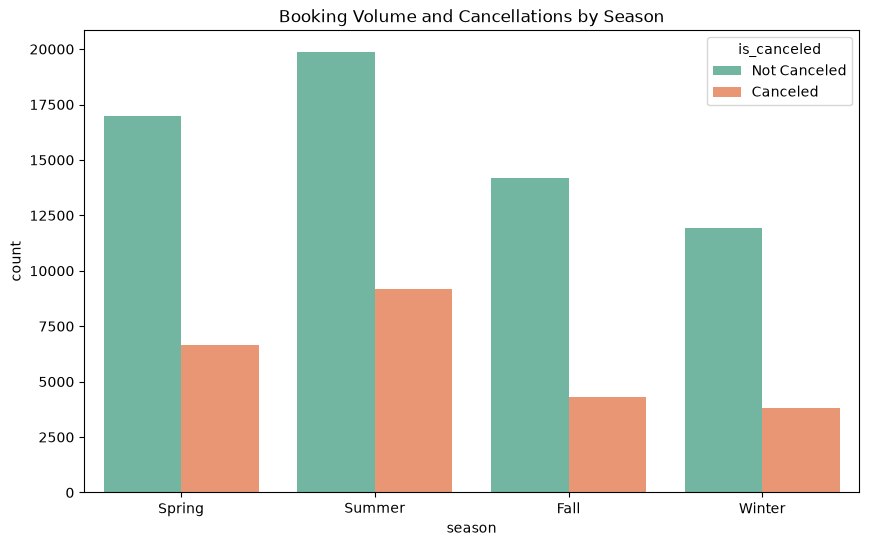

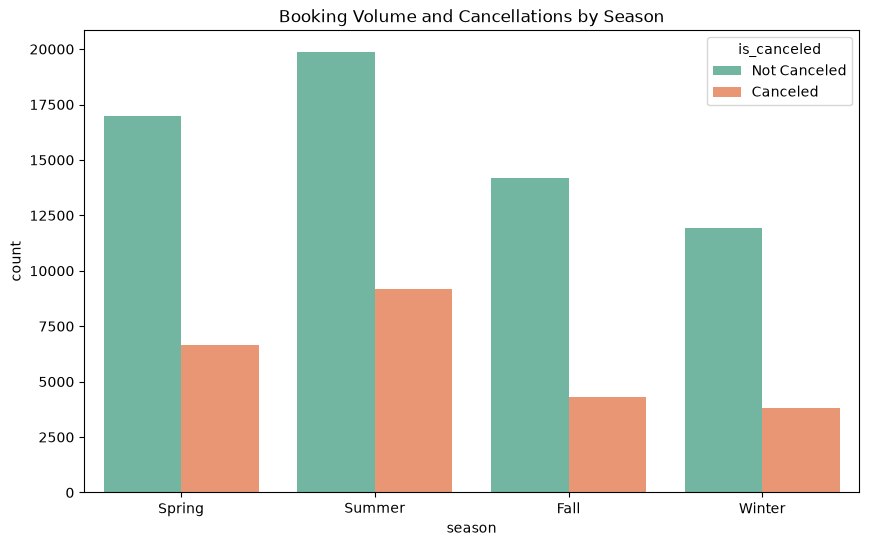

In [ ]:
# Seasonal cancellation analysis
plt.figure(figsize=(10,6))

# Define the seasonal order
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

df['season'] = df['season'].str.strip()

sns.countplot(
    x='season',
    hue='is_canceled',
    data=df,
    order=season_order,
    palette='Set2'
)
plt.title('Booking Volume and Cancellations by Season')
# Seasonal cancellation analysis
plt.figure(figsize=(10, 6))

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
df['season'] = df['season'].str.strip()

sns.countplot(
    x='season',
    hue='is_canceled',
    data=df,
    order=season_order,
    palette='Set2'
)

plt.title('Booking Volume and Cancellations by Season')
fig, ax = plt.subplots(figsize=(10, 6))

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
df['season'] = df['season'].str.strip()

sns.countplot(
    data=df,
    x='season',
    hue='is_canceled',
    order=season_order,
    palette='Set2',
    ax=ax
)

ax.set_title('Booking Volume and Cancellations by Season')
ax.set_ylabel('Number of Bookings')
ax.set_xlabel('Season')
ax.legend(title='Status')

plt.savefig('seasonal.png')
plt.show()
plt.xlabel('Season')
plt.legend(title='Status')
plt.savefig('seasonal.png')
plt.show()



Summer show the highest volume of bookings and the highest absolute number of cancellations.